# BirdCLEF 2026 — Exploratory Data Analysis
**Author:** Moritz  
**Focus:** `taxonomy.csv` and `sample_submission.csv`

Comprehensive analysis of the target classes and submission format for the BirdCLEF 2026 competition focusing on Pantanal biodiversity.

## 1. Setup & Imports

In [24]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#dee2e6',
    'axes.labelcolor': '#212529',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'text.color': '#212529',
    'grid.alpha': 0.3,
    'grid.color': '#dee2e6',
    'font.size': 11,
    'font.family': 'sans-serif',
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
})

CLASS_COLORS = {
    'Aves':     '#1565C0',
    'Amphibia': '#2E7D32',
    'Insecta':  '#F57C00',
    'Mammalia': '#6A1B9A',
    'Reptilia': '#AD1457',
}
BASE_COLOR = '#2196F3'

print('Imports and plotting configuration complete.')

Imports and plotting configuration complete.


## 2. Load Data

In [25]:
DATA_PATH = "../data/"

if not os.path.exists(DATA_PATH):
    print(f"ERROR: Data path not found: {DATA_PATH}")
else:
    print(f"Data directory: {DATA_PATH}")

taxonomy          = pd.read_csv(DATA_PATH + "taxonomy.csv")
sample_submission = pd.read_csv(DATA_PATH + "sample_submission.csv")

print(f"taxonomy.csv loaded:          {taxonomy.shape[0]:>6,} rows x {taxonomy.shape[1]:>3} columns")
print(f"sample_submission.csv loaded: {sample_submission.shape[0]:>6,} rows x {sample_submission.shape[1]:>3} columns")

Data directory: ../data/
taxonomy.csv loaded:             234 rows x   5 columns
sample_submission.csv loaded:      3 rows x 235 columns


## 3. Taxonomy Analysis

### 3.1 Dataset Structure

In [26]:
print("First 5 rows:")
display(taxonomy.head())

print("\nColumn names and data types:")
print(taxonomy.dtypes)

print(f"\nDataset shape: {taxonomy.shape}")
print(f"  - {taxonomy.shape[0]} total target species/entities")
print(f"  - {taxonomy.shape[1]} attributes per species")

First 5 rows:


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia



Column names and data types:
primary_label        str
inat_taxon_id      int64
scientific_name      str
common_name          str
class_name           str
dtype: object

Dataset shape: (234, 5)
  - 234 total target species/entities
  - 5 attributes per species


### 3.2 Data Quality Assessment

In [27]:
missing_values = taxonomy.isnull().sum()
print("Missing values per column:")
if missing_values.sum() == 0:
    print("  No missing values detected - dataset is complete!")
else:
    print(missing_values[missing_values > 0])

duplicates = taxonomy.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates == 0:
    print("  No duplicate entries found")

print("\nUnique values per column:")
for col in taxonomy.columns:
    print(f"  {col:20} : {taxonomy[col].nunique():>4} unique values")

Missing values per column:
  No missing values detected - dataset is complete!

Duplicate rows: 0
  No duplicate entries found

Unique values per column:
  primary_label        :  234 unique values
  inat_taxon_id        :  210 unique values
  scientific_name      :  234 unique values
  common_name          :  234 unique values
  class_name           :    5 unique values


### 3.3 Biological Class Distribution

In [28]:
class_counts = taxonomy['class_name'].value_counts()
class_percentages = (class_counts / class_counts.sum() * 100).round(2)

print("Species count by biological class:")
print(class_counts.to_string())
print(f"\nTotal classes represented: {taxonomy['class_name'].nunique()}")

print("\nPercentage distribution:")
for cls, pct in class_percentages.items():
    print(f"  {cls:15} : {pct:>6.2f}%")

Species count by biological class:
class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1

Total classes represented: 5

Percentage distribution:
  Aves            :  69.23%
  Amphibia        :  14.96%
  Insecta         :  11.97%
  Mammalia        :   3.42%
  Reptilia        :   0.43%


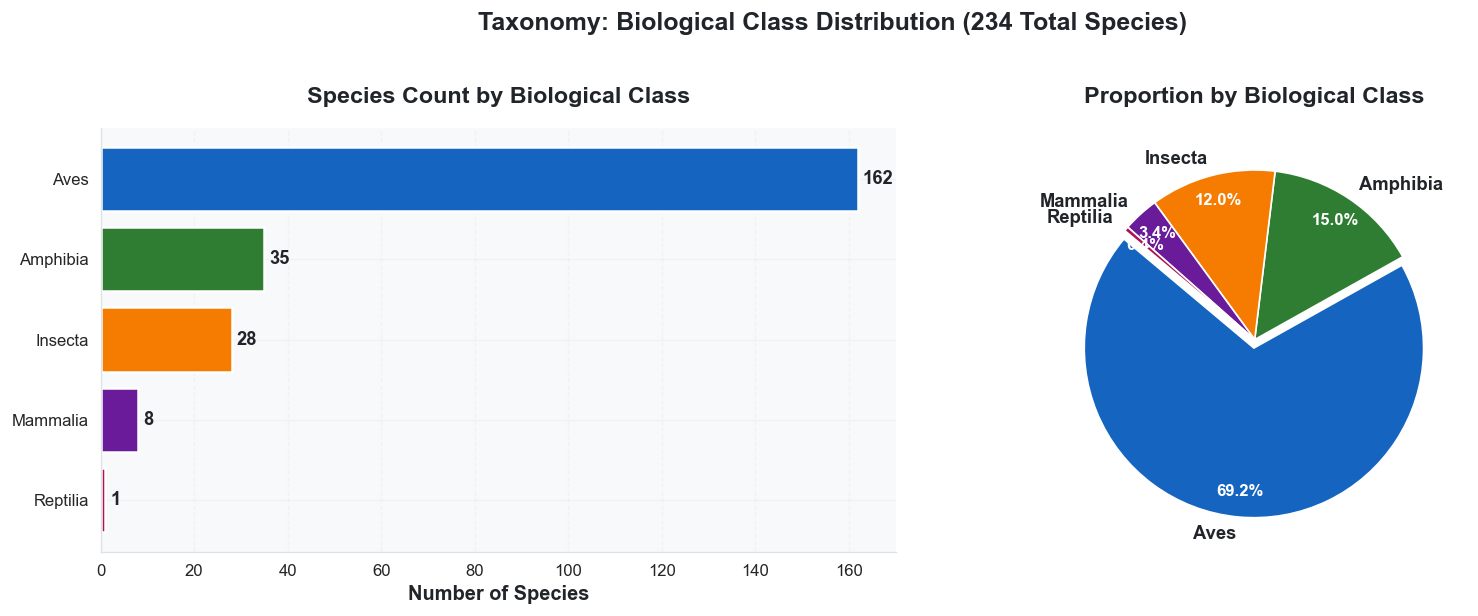

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_list = [CLASS_COLORS.get(cls, BASE_COLOR) for cls in class_counts.index]
bars = axes[0].barh(class_counts.index, class_counts.values,
                    color=colors_list, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Number of Species', fontweight='bold')
axes[0].set_title('Species Count by Biological Class', fontweight='bold', pad=15)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(val + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontweight='bold', fontsize=11)
axes[0].invert_yaxis()

wedges, texts, autotexts = axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=colors_list,
    startangle=140,
    pctdistance=0.85,
    explode=[0.05 if i == 0 else 0 for i in range(len(class_counts))]
)
for text in texts:
    text.set_fontsize(11); text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_color('white'); autotext.set_fontweight('bold'); autotext.set_fontsize(10)
axes[1].set_title('Proportion by Biological Class', fontweight='bold', pad=15)

plt.suptitle(f'Taxonomy: Biological Class Distribution ({len(taxonomy)} Total Species)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('taxonomy_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Sample Species per Biological Class

In [30]:
print("Showing 5 example species from each class:\n")
for cls in class_counts.index:
    subset = taxonomy[taxonomy['class_name'] == cls][['primary_label', 'scientific_name', 'common_name']].head(5)
    n_species = (taxonomy['class_name'] == cls).sum()
    print(f"{cls} ({n_species} species total):")
    for _, row in subset.iterrows():
        print(f"   {row['primary_label']:15} | {row['scientific_name']:30} | {row['common_name']}")
    print()

Showing 5 example species from each class:

Aves (162 species total):
   ashgre1         | Hylophilus pectoralis          | Ashy-headed Greenlet
   astcra1         | Mustelirallus albicollis       | Ash-throated Crake
   bafcur1         | Crax fasciolata                | Bare-faced Curassow
   baffal1         | Micrastur ruficollis           | Barred Forest-Falcon
   banana          | Coereba flaveola               | Bananaquit

Amphibia (35 species total):
   1176823         | Leptodactylus luctator         | Wrestler Frog
   1491113         | Adenomera guarani              | Guaraní leaf-litter frog
   1595929         | Lysapsus limellum              | Uruguay Harlequin Frog
   22930           | Leptodactylus syphax           | Basin White-lipped Frog
   22956           | Leptodactylus mystacinus       | Mustached Frog

Insecta (28 species total):
   1161364         | Guyalna cuta                   | Guyalna cuta
   244024          | Quesada gigas                  | Giant Cicada
   4

### 3.5 Class Imbalance Analysis

In [31]:
max_count      = class_counts.max()
min_count      = class_counts.min()
imbalance_ratio = max_count / min_count

print("Class imbalance metrics:")
print(f"  Most represented class  : {class_counts.idxmax()} ({max_count} species)")
print(f"  Least represented class : {class_counts.idxmin()} ({min_count} species)")
print(f"  Imbalance ratio         : {imbalance_ratio:.1f}:1")
print(f"  Mean species per class  : {class_counts.mean():.1f}")
print(f"  Median species per class: {class_counts.median():.0f}")
print()
print(f"Key Insight: The dataset shows significant class imbalance with {class_counts.idxmax()} having")
print(f"{imbalance_ratio:.1f}x more species than {class_counts.idxmin()}. This is expected as birds")
print("are the primary focus of acoustic monitoring in most ecosystems.")

Class imbalance metrics:
  Most represented class  : Aves (162 species)
  Least represented class : Reptilia (1 species)
  Imbalance ratio         : 162.0:1
  Mean species per class  : 46.8
  Median species per class: 28

Key Insight: The dataset shows significant class imbalance with Aves having
162.0x more species than Reptilia. This is expected as birds
are the primary focus of acoustic monitoring in most ecosystems.


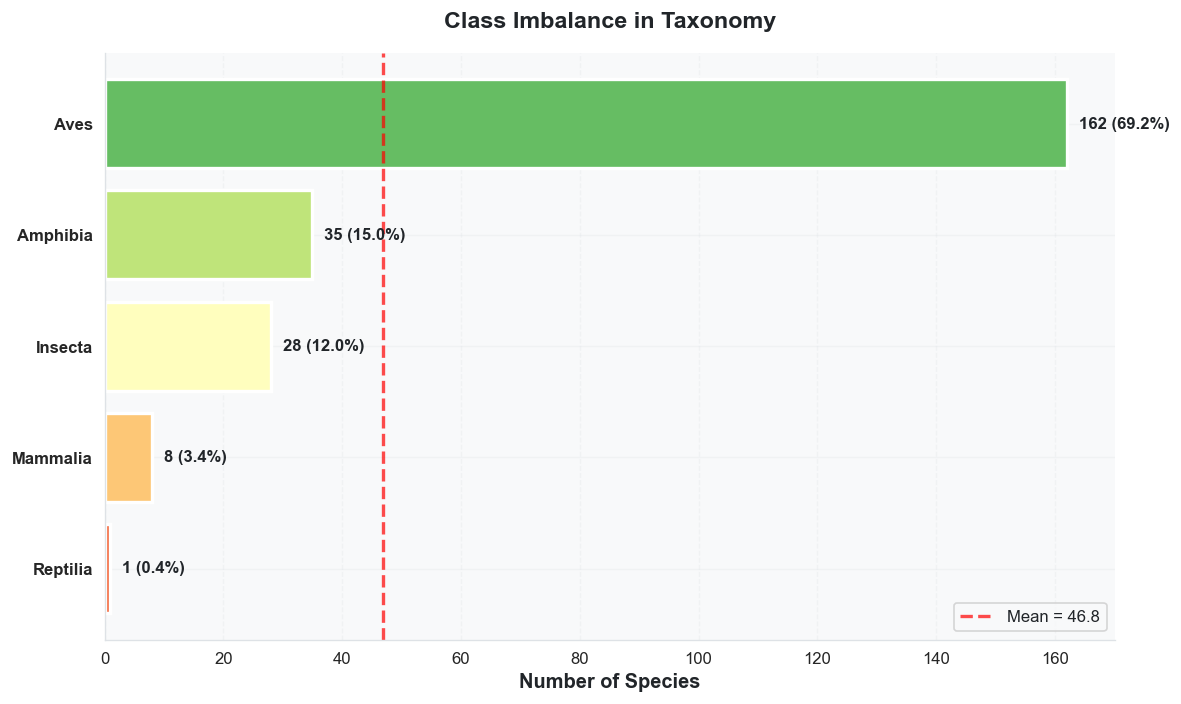

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

positions = np.arange(len(class_counts))
colors    = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(class_counts)))
bars = ax.barh(positions, class_counts.values, color=colors, edgecolor='white', linewidth=2)

ax.set_yticks(positions)
ax.set_yticklabels(class_counts.index, fontweight='bold')
ax.set_xlabel('Number of Species', fontweight='bold', fontsize=12)
ax.set_title('Class Imbalance in Taxonomy', fontweight='bold', fontsize=14, pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')

mean_val = class_counts.mean()
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
           label=f'Mean = {mean_val:.1f}', alpha=0.7)

for i, (bar, val) in enumerate(zip(bars, class_counts.values)):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'{val} ({class_percentages.iloc[i]:.1f}%)',
            va='center', fontweight='bold', fontsize=10)

ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('taxonomy_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sample Submission Analysis

### 4.1 Submission Format Structure

In [33]:
print("First 3 rows (showing first 6 columns):")
display(sample_submission.iloc[:3, :6])

print(f"\nDataset shape: {sample_submission.shape}")
print(f"  - {sample_submission.shape[0]} sample rows (test segments)")
print(f"  - {sample_submission.shape[1]} total columns")
print(f"  - 1 row_id column + {sample_submission.shape[1] - 1} species prediction columns")

cols = sample_submission.columns.tolist()
print(f"\nFirst 10 species columns : {cols[1:11]}")
print(f"Last 5 columns           : {cols[-5:]}")

First 3 rows (showing first 6 columns):


,row_id,1161364,116570,1176823,1491113,1595929
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274



Dataset shape: (3, 235)
  - 3 sample rows (test segments)
  - 235 total columns
  - 1 row_id column + 234 species prediction columns

First 10 species columns : ['1161364', '116570', '1176823', '1491113', '1595929', '209233', '22930', '22956', '22961', '22967']
Last 5 columns           : ['yebela1', 'yecmac', 'yecpar', 'yehcar1', 'yeofly1']


### 4.2 Row ID Format Analysis

In [34]:
print("Sample row_id values:")
for i, row_id in enumerate(sample_submission['row_id'].head()):
    print(f"  {i+1}. {row_id}")

print("\nRow ID structure: BC2026_Test_[file]_[site]_[datetime]_[segment]")
print("\n  Example: BC2026_Test_0001_S05_20250227_010002_5")
print("    - Competition : BC2026 (BirdCLEF 2026)")
print("    - Split       : Test")
print("    - File ID     : 0001")
print("    - Site        : S05")
print("    - Date        : 20250227 (2025-02-27)")
print("    - Time        : 010002 (01:00:02)")
print("    - Segment     : 5 (5-second window position)")

Sample row_id values:
  1. BC2026_Test_0001_S05_20250227_010002_5
  2. BC2026_Test_0001_S05_20250227_010002_10
  3. BC2026_Test_0001_S05_20250227_010002_15

Row ID structure: BC2026_Test_[file]_[site]_[datetime]_[segment]

  Example: BC2026_Test_0001_S05_20250227_010002_5
    - Competition : BC2026 (BirdCLEF 2026)
    - Split       : Test
    - File ID     : 0001
    - Site        : S05
    - Date        : 20250227 (2025-02-27)
    - Time        : 010002 (01:00:02)
    - Segment     : 5 (5-second window position)


### 4.3 Baseline Prediction Values

In [35]:
species_cols   = sample_submission.columns[1:]
initial_values = sample_submission[species_cols].iloc[0].unique()

print(f"Baseline prediction value : {initial_values}")
print(f"All predictions identical : {len(initial_values) == 1}")

if len(initial_values) == 1:
    baseline_val = initial_values[0]
    print(f"Value                     : {baseline_val:.6f}")
    print(f"Interpretation            : Uniform probability across {len(species_cols)} classes")
    print(f"1 / {len(species_cols)} = {1/len(species_cols):.6f}")

all_values = sample_submission[species_cols].values.flatten()
print(f"\nValue range  : [{all_values.min():.6f}, {all_values.max():.6f}]")
print(f"All in [0,1] : {(all_values >= 0).all() and (all_values <= 1).all()}")

Baseline prediction value : [0.0042735]
All predictions identical : True
Value                     : 0.004274
Interpretation            : Uniform probability across 234 classes
1 / 234 = 0.004274

Value range  : [0.004274, 0.004274]
All in [0,1] : True


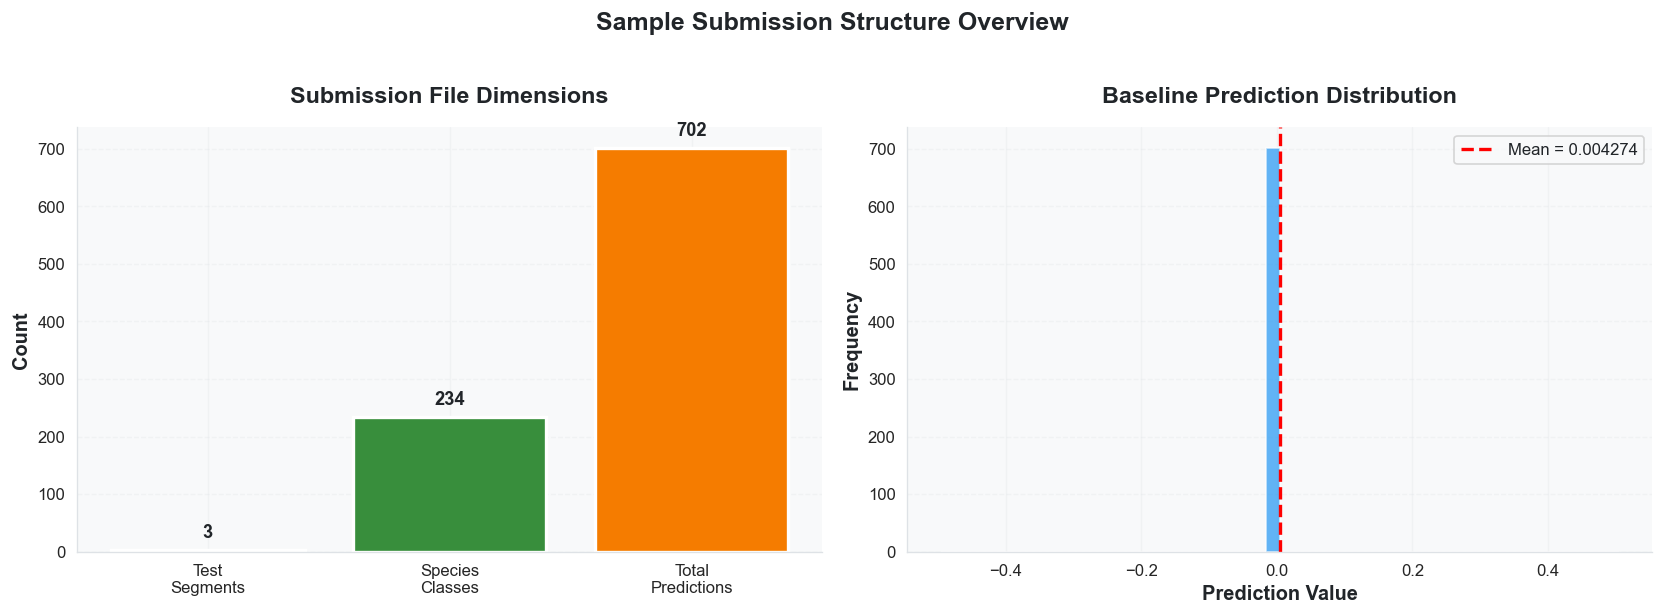

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dimensions = {
    'Test\nSegments':       sample_submission.shape[0],
    'Species\nClasses':     sample_submission.shape[1] - 1,
    'Total\nPredictions':   sample_submission.shape[0] * (sample_submission.shape[1] - 1)
}
colors_dim = ['#1976D2', '#388E3C', '#F57C00']
bars = axes[0].bar(dimensions.keys(), dimensions.values(), color=colors_dim, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('Submission File Dimensions', fontweight='bold', pad=15)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
for bar, (key, val) in zip(bars, dimensions.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(dimensions.values())*0.02,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

axes[1].hist(all_values, bins=50, color=BASE_COLOR, edgecolor='white', alpha=0.7)
axes[1].axvline(all_values.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean = {all_values.mean():.6f}')
axes[1].set_xlabel('Prediction Value', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Baseline Prediction Distribution', fontweight='bold', pad=15)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Sample Submission Structure Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('submission_structure.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cross-Validation: Taxonomy ↔ Submission Alignment

### 5.1 Species Set Alignment

In [37]:
taxonomy_species   = set(taxonomy['primary_label'].astype(str))
submission_species = set(sample_submission.columns[1:])

missing_in_submission = taxonomy_species - submission_species
extra_in_submission   = submission_species - taxonomy_species

print(f"Species in taxonomy   : {len(taxonomy_species)}")
print(f"Species in submission : {len(submission_species)}")

if len(taxonomy_species) == len(submission_species):
    print("Count match: Number of species is identical")
else:
    print(f"Count mismatch: Difference of {abs(len(taxonomy_species) - len(submission_species))} species")

if len(missing_in_submission) == 0:
    print("Coverage: All taxonomy species present in submission columns")
else:
    print(f"Coverage issue: {len(missing_in_submission)} species missing in submission")
    print(f"  Missing: {list(missing_in_submission)[:10]}...")

if len(extra_in_submission) == 0:
    print("No extra species: Submission contains only taxonomy species")
else:
    print(f"Extra species: {len(extra_in_submission)} in submission not in taxonomy")

submission_cols_sorted = sorted(sample_submission.columns[1:])
is_sorted = list(sample_submission.columns[1:]) == submission_cols_sorted
print(f"\nSubmission columns alphabetically sorted: {is_sorted}")

Species in taxonomy   : 234
Species in submission : 234
Count match: Number of species is identical
Coverage: All taxonomy species present in submission columns
No extra species: Submission contains only taxonomy species

Submission columns alphabetically sorted: True


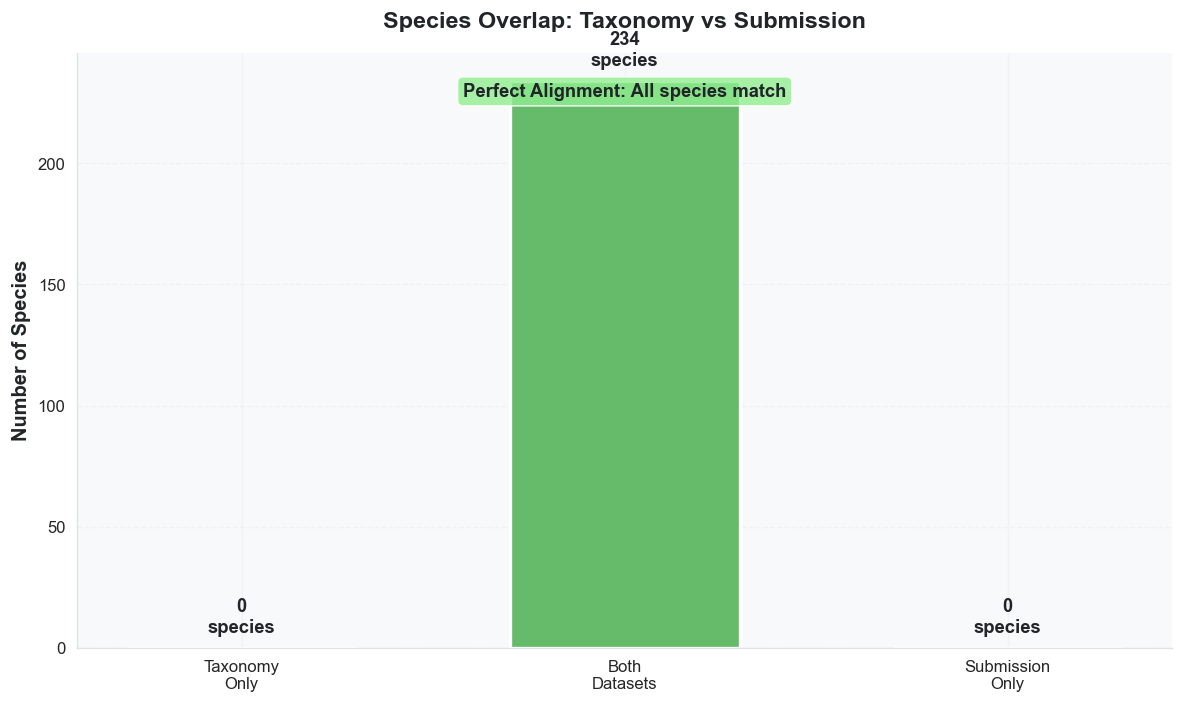

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Taxonomy\nOnly', 'Both\nDatasets', 'Submission\nOnly']
values     = [len(missing_in_submission), len(taxonomy_species & submission_species), len(extra_in_submission)]
colors_venn = ['#EF5350', '#66BB6A', '#FFA726']

bars = ax.bar(categories, values, color=colors_venn, edgecolor='white', linewidth=2, width=0.6)
ax.set_ylabel('Number of Species', fontweight='bold', fontsize=12)
ax.set_title('Species Overlap: Taxonomy vs Submission', fontweight='bold', fontsize=14, pad=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.02,
            f'{val}\nspecies', ha='center', va='bottom', fontweight='bold', fontsize=11)

if all(v == 0 for v in [values[0], values[2]]):
    ax.text(0.5, 0.95, 'Perfect Alignment: All species match',
            transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('taxonomy_submission_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Biological Class Breakdown in Submission

In [39]:
species_to_class = dict(zip(taxonomy['primary_label'], taxonomy['class_name']))

submission_class_counts = {}
for species in sample_submission.columns[1:]:
    cls = species_to_class.get(species, 'Unknown')
    submission_class_counts[cls] = submission_class_counts.get(cls, 0) + 1

submission_class_df = pd.DataFrame([
    {'class_name': cls, 'count': cnt}
    for cls, cnt in submission_class_counts.items()
]).sort_values('count', ascending=False)

print("Submission targets by biological class:")
for _, row in submission_class_df.iterrows():
    pct = row['count'] / (sample_submission.shape[1] - 1) * 100
    print(f"  {row['class_name']:15} : {row['count']:>3} species ({pct:>5.1f}%)")

Submission targets by biological class:
  Aves            : 162 species ( 69.2%)
  Amphibia        :  35 species ( 15.0%)
  Insecta         :  28 species ( 12.0%)
  Mammalia        :   8 species (  3.4%)
  Reptilia        :   1 species (  0.4%)


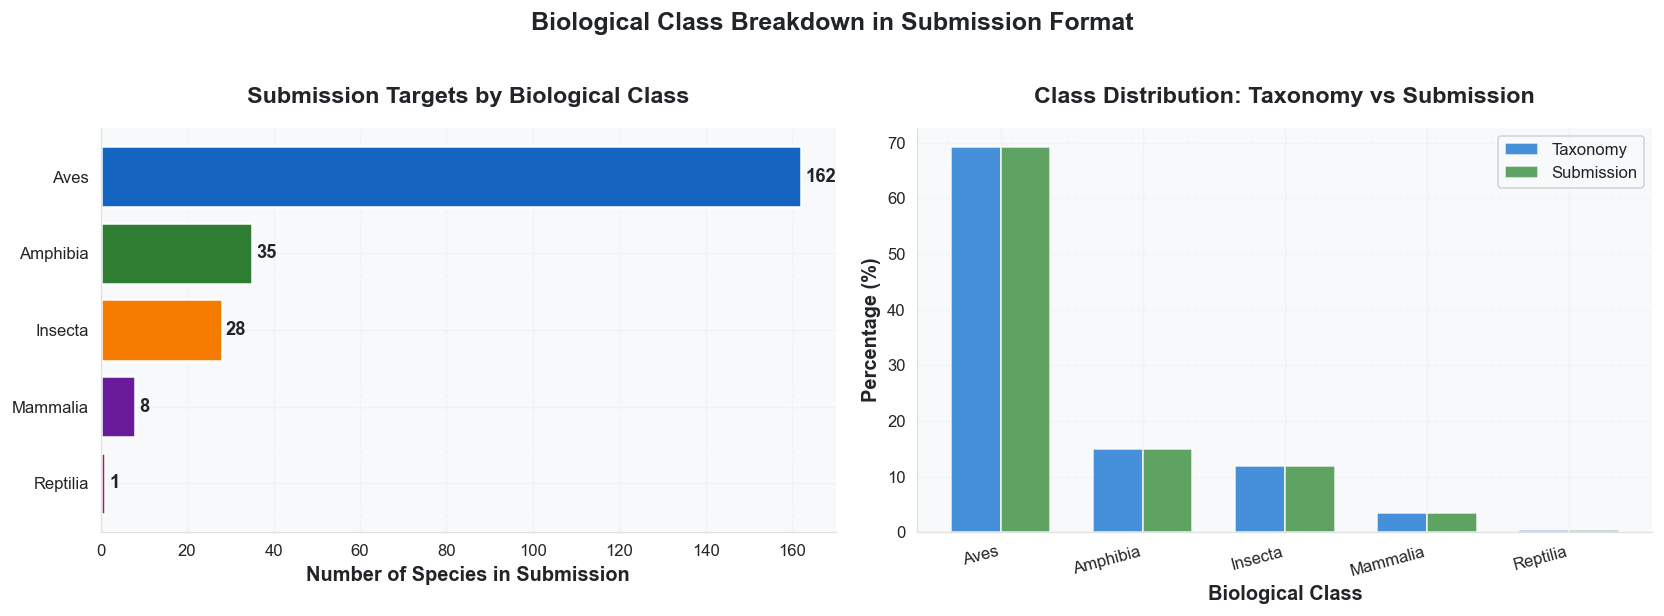

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_sub = [CLASS_COLORS.get(cls, '#999999') for cls in submission_class_df['class_name']]
bars = axes[0].barh(submission_class_df['class_name'], submission_class_df['count'],
                    color=colors_sub, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Number of Species in Submission', fontweight='bold')
axes[0].set_title('Submission Targets by Biological Class', fontweight='bold', pad=15)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].invert_yaxis()
for bar, val in zip(bars, submission_class_df['count']):
    axes[0].text(val + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontweight='bold', fontsize=11)

class_comparison = pd.DataFrame({
    'Class': class_counts.index,
    'Taxonomy %': (class_counts / class_counts.sum() * 100).values
})
sub_pcts = []
for cls in class_comparison['Class']:
    match = submission_class_df[submission_class_df['class_name'] == cls]
    sub_pcts.append(match['count'].values[0] / submission_class_df['count'].sum() * 100 if not match.empty else 0)
class_comparison['Submission %'] = sub_pcts

x = np.arange(len(class_comparison))
width = 0.35
axes[1].bar(x - width/2, class_comparison['Taxonomy %'],   width, label='Taxonomy',   color='#1976D2', alpha=0.8)
axes[1].bar(x + width/2, class_comparison['Submission %'], width, label='Submission', color='#388E3C', alpha=0.8)
axes[1].set_xlabel('Biological Class', fontweight='bold')
axes[1].set_ylabel('Percentage (%)', fontweight='bold')
axes[1].set_title('Class Distribution: Taxonomy vs Submission', fontweight='bold', pad=15)
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_comparison['Class'], rotation=15, ha='right')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Biological Class Breakdown in Submission Format', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('submission_class_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary Statistics & Key Insights

In [41]:
summary_data = [
    ['TAXONOMY TABLE', ''],
    ['  Total species/entities',  f'{len(taxonomy):,}'],
    ['  Biological classes',       f'{taxonomy["class_name"].nunique()}'],
    ['  Most common class',        f'{class_counts.idxmax()} ({class_counts.max()} species)'],
    ['  Least common class',       f'{class_counts.idxmin()} ({class_counts.min()} species)'],
    ['  Class imbalance ratio',    f'{class_counts.max() / class_counts.min():.1f}:1'],
    ['', ''],
    ['SAMPLE SUBMISSION', ''],
    ['  Test segments (rows)',     f'{sample_submission.shape[0]:,}'],
    ['  Target classes (columns)', f'{sample_submission.shape[1] - 1:,}'],
    ['  Total predictions needed', f'{sample_submission.shape[0] * (sample_submission.shape[1] - 1):,}'],
    ['  Baseline prediction value',f'{initial_values[0]:.6f}'],
    ['  Prediction format',        'Probabilities [0, 1]'],
    ['', ''],
    ['ALIGNMENT CHECK', ''],
    ['  Taxonomy species count',   f'{len(taxonomy_species)}'],
    ['  Submission species count', f'{len(submission_species)}'],
    ['  Perfect match',            'Yes' if len(missing_in_submission) == 0 and len(extra_in_submission) == 0 else 'No'],
]

summary_df = pd.DataFrame(summary_data, columns=['Metric', 'Value'])
print(summary_df.to_string(index=False))

                     Metric                Value
             TAXONOMY TABLE                     
     Total species/entities                  234
         Biological classes                    5
          Most common class   Aves (162 species)
         Least common class Reptilia (1 species)
      Class imbalance ratio              162.0:1
                                                
          SAMPLE SUBMISSION                     
       Test segments (rows)                    3
   Target classes (columns)                  234
   Total predictions needed                  702
  Baseline prediction value             0.004274
          Prediction format Probabilities [0, 1]
                                                
            ALIGNMENT CHECK                     
     Taxonomy species count                  234
   Submission species count                  234
              Perfect match                  Yes


In [42]:
print("INSIGHT 1: Multi-Class Biodiversity Challenge")
print("  This is NOT just a bird classification task. The dataset includes:")
for cls, cnt in class_counts.items():
    pct = cnt / class_counts.sum() * 100
    print(f"    {cls:12} : {cnt:3} species ({pct:5.1f}%)")

print()
print("INSIGHT 2: Severe Class Imbalance")
print(f"  Aves dominates with {class_counts['Aves']} species ({class_percentages['Aves']:.1f}%),")
print(f"  while Reptilia has only {class_counts.get('Reptilia', 0)} species.")
print("  -> Use class-weighted loss or specialized sampling strategies")

print()
print("INSIGHT 3: Submission Format Requirements")
print(f"  Multi-label classification: {sample_submission.shape[1] - 1} simultaneous predictions")
print("  Output format: Probabilities (0 to 1) for each species")
print("  Evaluation: Likely ROC-AUC or similar metric across all classes")

print()
print("INSIGHT 4: Perfect Taxonomy-Submission Alignment")
if len(missing_in_submission) == 0 and len(extra_in_submission) == 0:
    print("  All taxonomy species match submission columns exactly — no extra mapping required.")
else:
    print("  Some misalignment detected — verify before model training.")

INSIGHT 1: Multi-Class Biodiversity Challenge
  This is NOT just a bird classification task. The dataset includes:
    Aves         : 162 species ( 69.2%)
    Amphibia     :  35 species ( 15.0%)
    Insecta      :  28 species ( 12.0%)
    Mammalia     :   8 species (  3.4%)
    Reptilia     :   1 species (  0.4%)

INSIGHT 2: Severe Class Imbalance
  Aves dominates with 162 species (69.2%),
  while Reptilia has only 1 species.
  -> Use class-weighted loss or specialized sampling strategies

INSIGHT 3: Submission Format Requirements
  Multi-label classification: 234 simultaneous predictions
  Output format: Probabilities (0 to 1) for each species
  Evaluation: Likely ROC-AUC or similar metric across all classes

INSIGHT 4: Perfect Taxonomy-Submission Alignment
  All taxonomy species match submission columns exactly — no extra mapping required.


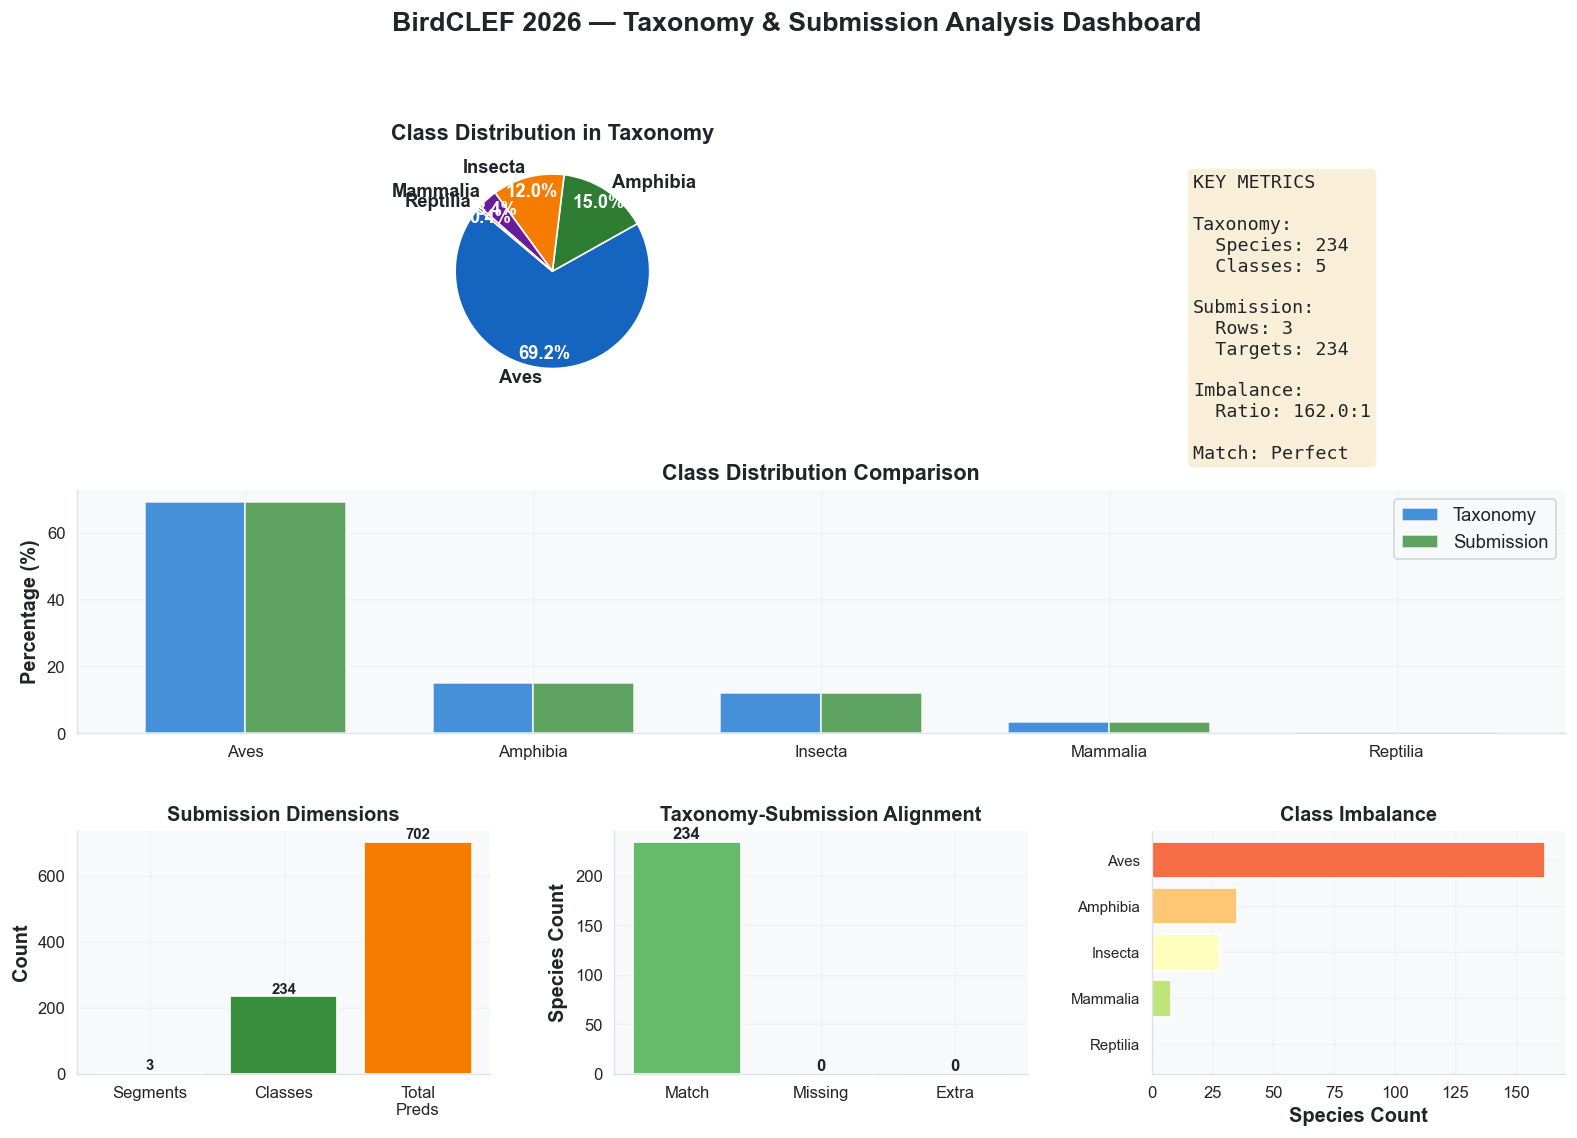

In [43]:
fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# Class distribution pie
ax1 = fig.add_subplot(gs[0, :2])
colors_pie = [CLASS_COLORS.get(cls, '#999999') for cls in class_counts.index]
wedges, texts, autotexts = ax1.pie(
    class_counts.values, labels=class_counts.index,
    autopct='%1.1f%%', colors=colors_pie, startangle=140, pctdistance=0.85
)
for t in texts:     t.set_fontsize(11); t.set_fontweight('bold')
for a in autotexts: a.set_color('white'); a.set_fontweight('bold')
ax1.set_title('Class Distribution in Taxonomy', fontweight='bold', fontsize=13)

# Key metrics text box
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
metrics_text = (
    f"KEY METRICS\n\nTaxonomy:\n  Species: {len(taxonomy)}\n  Classes: {taxonomy['class_name'].nunique()}\n\n"
    f"Submission:\n  Rows: {sample_submission.shape[0]}\n  Targets: {sample_submission.shape[1]-1}\n\n"
    f"Imbalance:\n  Ratio: {class_counts.max()/class_counts.min():.1f}:1\n\n"
    f"Match: {'Perfect' if len(missing_in_submission)==0 else 'Issues'}"
)
ax2.text(0.1, 0.9, metrics_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Class comparison bars
ax3 = fig.add_subplot(gs[1, :])
x = np.arange(len(class_comparison))
ax3.bar(x - 0.175, class_comparison['Taxonomy %'],   0.35, label='Taxonomy',   color='#1976D2', alpha=0.8)
ax3.bar(x + 0.175, class_comparison['Submission %'], 0.35, label='Submission', color='#388E3C', alpha=0.8)
ax3.set_ylabel('Percentage (%)', fontweight='bold')
ax3.set_title('Class Distribution Comparison', fontweight='bold', fontsize=13)
ax3.set_xticks(x); ax3.set_xticklabels(class_comparison['Class'])
ax3.legend(); ax3.grid(axis='y', alpha=0.3)

# Submission dimensions
ax4 = fig.add_subplot(gs[2, 0])
dims_vals = [sample_submission.shape[0], sample_submission.shape[1]-1,
             sample_submission.shape[0]*(sample_submission.shape[1]-1)]
bars = ax4.bar(['Segments', 'Classes', 'Total\nPreds'], dims_vals, color=['#1976D2','#388E3C','#F57C00'])
ax4.set_title('Submission Dimensions', fontweight='bold', fontsize=12)
ax4.set_ylabel('Count', fontweight='bold'); ax4.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, dims_vals):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{val:,}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# Alignment
ax5 = fig.add_subplot(gs[2, 1])
align_vals = [len(taxonomy_species & submission_species), len(missing_in_submission), len(extra_in_submission)]
bars = ax5.bar(['Match', 'Missing', 'Extra'], align_vals, color=['#66BB6A','#EF5350','#FFA726'])
ax5.set_title('Taxonomy-Submission Alignment', fontweight='bold', fontsize=12)
ax5.set_ylabel('Species Count', fontweight='bold'); ax5.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, align_vals):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height(), str(val),
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Class imbalance
ax6 = fig.add_subplot(gs[2, 2])
sorted_classes = class_counts.sort_values(ascending=True)
colors_imb = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(sorted_classes)))
ax6.barh(range(len(sorted_classes)), sorted_classes.values, color=colors_imb)
ax6.set_yticks(range(len(sorted_classes)))
ax6.set_yticklabels(sorted_classes.index, fontsize=9)
ax6.set_title('Class Imbalance', fontweight='bold', fontsize=12)
ax6.set_xlabel('Species Count', fontweight='bold'); ax6.grid(axis='x', alpha=0.3)

plt.suptitle('BirdCLEF 2026 — Taxonomy & Submission Analysis Dashboard',
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig('eda_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Modeling Recommendations

In [44]:
n_classes = sample_submission.shape[1] - 1
n_rows    = sample_submission.shape[0]
n_cols    = sample_submission.shape[1]

print(f"""
1. HANDLE CLASS IMBALANCE
   - Use weighted Binary Cross-Entropy loss with class weights
   - Consider focal loss to focus on hard-to-classify species
   - Implement class-balanced sampling during training

2. MULTI-LABEL CLASSIFICATION SETUP
   - Model must output {n_classes} independent probabilities
   - Use sigmoid activation (not softmax) for final layer
   - Each species prediction is independent

3. ACCOUNT FOR BIODIVERSITY
   - Different acoustic signatures for different animal classes
   - Birds (high freq) vs Amphibians (low freq) vs Insects (broadband)
   - Consider separate feature extractors or attention mechanisms

4. EVALUATION METRIC PREPARATION
   - Likely ROC-AUC macro-averaged across all classes
   - Ensure model outputs well-calibrated probabilities in [0,1]
   - Consider per-class threshold optimization

5. SUBMISSION FORMAT COMPLIANCE
   - Validate output shape: {n_rows} rows x {n_cols} columns
   - Ensure all probabilities are in [0, 1] range
   - Maintain exact column order as sample_submission.csv
""")


1. HANDLE CLASS IMBALANCE
   - Use weighted Binary Cross-Entropy loss with class weights
   - Consider focal loss to focus on hard-to-classify species
   - Implement class-balanced sampling during training

2. MULTI-LABEL CLASSIFICATION SETUP
   - Model must output 234 independent probabilities
   - Use sigmoid activation (not softmax) for final layer
   - Each species prediction is independent

3. ACCOUNT FOR BIODIVERSITY
   - Different acoustic signatures for different animal classes
   - Birds (high freq) vs Amphibians (low freq) vs Insects (broadband)
   - Consider separate feature extractors or attention mechanisms

4. EVALUATION METRIC PREPARATION
   - Likely ROC-AUC macro-averaged across all classes
   - Ensure model outputs well-calibrated probabilities in [0,1]
   - Consider per-class threshold optimization

5. SUBMISSION FORMAT COMPLIANCE
   - Validate output shape: 3 rows x 235 columns
   - Ensure all probabilities are in [0, 1] range
   - Maintain exact column order as sam

## 9. Save Report & Conclusion

In [45]:
report_lines = [
    '=' * 70,
    'BirdCLEF 2026 - EDA REPORT',
    'Focus: Taxonomy & Sample Submission Analysis',
    '=' * 70,
    '',
    'DATASET OVERVIEW',
    '-' * 70,
    f'Taxonomy entries:          {len(taxonomy):>10,}',
    f'Biological classes:        {taxonomy["class_name"].nunique():>10}',
    f'Submission test segments:  {sample_submission.shape[0]:>10,}',
    f'Target prediction classes: {sample_submission.shape[1] - 1:>10,}',
    '',
    'CLASS DISTRIBUTION',
    '-' * 70,
]
for cls, cnt in class_counts.items():
    pct = cnt / class_counts.sum() * 100
    report_lines.append(f'{cls:15} : {cnt:>3} species ({pct:>5.1f}%)')

report_lines += [
    '',
    'CLASS IMBALANCE METRICS',
    '-' * 70,
    f'Most represented:  {class_counts.idxmax()} ({class_counts.max()} species)',
    f'Least represented: {class_counts.idxmin()} ({class_counts.min()} species)',
    f'Imbalance ratio:   {class_counts.max() / class_counts.min():.1f}:1',
    '',
    'ALIGNMENT CHECK',
    '-' * 70,
    f'Taxonomy species:        {len(taxonomy_species)}',
    f'Submission species:      {len(submission_species)}',
    f'Species in both:         {len(taxonomy_species & submission_species)}',
    f'Missing from submission: {len(missing_in_submission)}',
    f'Extra in submission:     {len(extra_in_submission)}',
    f'Perfect match: {"YES" if len(missing_in_submission)==0 and len(extra_in_submission)==0 else "NO"}',
    '',
    '=' * 70,
    'END OF REPORT',
    '=' * 70,
]

with open('eda_summary_report.txt', 'w') as f:
    f.write('\n'.join(report_lines))

print('Summary report saved: eda_summary_report.txt')
print()
print('Generated figures:')
for fig_name in [
    'taxonomy_class_distribution.png',
    'taxonomy_class_imbalance.png',
    'submission_structure.png',
    'taxonomy_submission_alignment.png',
    'submission_class_breakdown.png',
    'eda_summary_dashboard.png',
]:
    print(f'  {fig_name}')
print()
print('Next steps:')
print('  1. Review class imbalance  -> Design sampling strategy')
print('  2. Multi-label format      -> Configure model output layer')
print('  3. Biodiversity            -> Consider multi-class acoustic features')
print('  4. Validate submission     -> Ensure compliance before submission')

Summary report saved: eda_summary_report.txt

Generated figures:
  taxonomy_class_distribution.png
  taxonomy_class_imbalance.png
  submission_structure.png
  taxonomy_submission_alignment.png
  submission_class_breakdown.png
  eda_summary_dashboard.png

Next steps:
  1. Review class imbalance  -> Design sampling strategy
  2. Multi-label format      -> Configure model output layer
  3. Biodiversity            -> Consider multi-class acoustic features
  4. Validate submission     -> Ensure compliance before submission
